### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

### Loading the Data

In [2]:
df = pd.read_csv("final_delivery_data.csv")
print(f'Total rows: {len(df):,}')
print(f'Data split: {df["data"].value_counts().to_dict()}')
df = df[df["data"] == "training"].copy()
df.head()

Total rows: 103,014
Data split: {'training': 103014}


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,is_night,hour,is_outlier,factor_capped,segment_factor_capped,time_gap,distance_efficiency,is_delayed,trip_duration,corridor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,False,2,False,1.272727,1.272727,3.0,0.872160,True,86.213637,IND388121AAA→IND388620AAB
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,False,2,False,1.200000,1.111111,4.0,0.871689,False,86.213637,IND388121AAA→IND388620AAB
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,False,2,False,1.428571,2.285714,12.0,0.849346,True,86.213637,IND388121AAA→IND388620AAB
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,False,2,False,1.550000,1.750000,22.0,0.792723,True,86.213637,IND388121AAA→IND388620AAB
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,False,2,False,1.545455,1.200000,24.0,0.726437,False,86.213637,IND388121AAA→IND388620AAB


### Building the Directed Graph

In [3]:
# Saving the final df
df.to_csv("final_delivery_data", index = False)

Each unique source_center --> destination_center pair becomes a directed edge
I have constructed two types of graphs:
- `G_all` - single graph with all trips (edge weights = median segment_factor)
- `G_rtype` - graph stratified by route type (FTL vs Carting attributes stored on edges)

#### G_all - Combined Graph With All Route Types

In [4]:
G_all = nx.DiGraph()

In [5]:
# Add nodes with attributes
all_nodes = set(df['source_center'].unique()) | set(df['destination_center'].unique())
for node in all_nodes:
    G_all.add_node(node)

In [6]:
# Compute per-corridor edge attributes
corridor_stats = (df.groupby(['source_center', 'destination_center']).agg(
        median_segment_factor   = ('segment_factor', 'median'),
        mean_segment_factor     = ('segment_factor', 'mean'),
        median_factor           = ('factor', 'median'),
        trip_count              = ('trip_uuid', 'count'),
        pct_delayed             = ('is_delayed', 'mean'),
        median_actual_time      = ('segment_actual_time', 'median'),
        median_osrm_time        = ('segment_osrm_time', 'median'),
        median_osrm_distance    = ('segment_osrm_distance', 'median'),
        total_excess_time=('time_gap', 'sum'),
        avg_excess_time=('time_gap', 'mean')).reset_index())

In [7]:
# Ranking corridor stats by SLA breach contribution
corridor_stats.sort_values('total_excess_time', ascending=False)

corridor_stats

,source_center,destination_center,median_segment_factor,mean_segment_factor,median_factor,trip_count,pct_delayed,median_actual_time,median_osrm_time,median_osrm_distance,total_excess_time,avg_excess_time
0,IND000000AAL,IND411033AAA,2.166667,2.705398,2.166667,27,1.000000,29.0,15.0,14.14880,879.0,32.555556
1,IND000000AAS,IND783370AAC,1.833333,2.580453,1.711279,18,1.000000,35.0,14.5,20.94415,444.0,24.666667
2,IND000000AAZ,IND444203AAA,3.208333,4.059096,4.365854,3,1.000000,101.0,24.0,32.86350,432.0,144.000000
3,IND000000AAZ,IND444303AAA,2.266184,2.266184,3.021739,2,1.000000,79.5,34.0,46.85345,144.0,72.000000
4,IND000000ABA,IND683565AAA,1.000000,1.138462,1.000000,5,0.200000,22.0,21.0,18.69900,9.0,1.800000
...,...,...,...,...,...,...,...,...,...,...,...,...
2503,IND854334AAA,IND852118AAA,1.333333,1.319728,1.333333,7,1.000000,28.0,21.0,23.87700,48.0,6.857143
2504,IND854334AAA,IND854335AAA,1.358974,1.429487,1.356322,4,0.750000,20.0,14.0,17.51180,41.0,10.250000
2505,IND854335AAA,IND852111AAA,1.764706,3.677940,1.764706,23,0.956522,26.0,16.0,23.48770,408.0,17.739130
2506,IND854335AAA,IND852118A1B,5.187500,5.187500,1.798611,2,1.000000,20.0,9.0,13.36310,28.0,14.000000


In [8]:
# Add edges
for _, row in corridor_stats.iterrows():
    G_all.add_edge(
        row['source_center'],
        row['destination_center'],
        weight = row['median_segment_factor'], 
        median_factor = row['median_factor'],
        trip_count = row['trip_count'],
        pct_delayed = row['pct_delayed'],
        median_actual_time = row['median_actual_time'],
        median_osrm_time = row['median_osrm_time'],
        median_osrm_distance = row['median_osrm_distance'],
        is_chronic_delay = row['median_segment_factor'] > 1.2,
        total_excess_time = row['total_excess_time'])

print(f"G_all: Nodes - {G_all.number_of_nodes():,}  |  Edges - {G_all.number_of_edges():,}")

G_all: Nodes - 1,590  |  Edges - 2,508


#### G_rtype - Route Type and Time Stratified Graph

In [9]:
G_rtype = nx.DiGraph()

In [10]:
# Add nodes
for node in all_nodes:
    G_rtype.add_node(node)

In [11]:
# Converting to datetime
df['od_start_time'] = pd.to_datetime(df['od_start_time'])

# Creating time buckets
df['tod_bucket'] = pd.cut(
    df['od_start_time'].dt.hour,
    bins=[-1, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening'],
    include_lowest=True,
    right=False
)

In [12]:
# Compute per-corridor-per-routetype-per-time stats
rtype_stats = (df.groupby([
        'source_center',
        'destination_center',
        'route_type',
        'tod_bucket'
    ]).agg(
        median_segment_factor=('segment_factor', 'median'),
        trip_count=('trip_uuid', 'count'),
        pct_delayed=('is_delayed', 'mean')).reset_index())

# Combine route type and time bucket
rtype_stats['route_time'] = (
    rtype_stats['route_type'].astype(str)
    + '_'
    + rtype_stats['tod_bucket'].astype(str))

rtype_stats.head()

C:\Users\Sri Vaishnavi\AppData\Local\Temp\ipykernel_7460\3500168784.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rtype_stats = (df.groupby([


,source_center,destination_center,route_type,tod_bucket,median_segment_factor,trip_count,pct_delayed,route_time
0,IND000000AAL,IND000000AAL,Carting,Night,NaN,0,NaN,Carting_Night
1,IND000000AAL,IND000000AAL,Carting,Morning,NaN,0,NaN,Carting_Morning
2,IND000000AAL,IND000000AAL,Carting,Afternoon,NaN,0,NaN,Carting_Afternoon
3,IND000000AAL,IND000000AAL,Carting,Evening,NaN,0,NaN,Carting_Evening
4,IND000000AAL,IND000000AAL,FTL,Night,NaN,0,NaN,FTL_Night


In [13]:
rtype_pivot = rtype_stats.pivot_table(
    index=[
        'source_center',
        'destination_center'
    ],
    columns='route_time',
    values=[
        'median_segment_factor',
        'trip_count',
        'pct_delayed'
    ]
).reset_index()

rtype_pivot.head()

source_center destination_center median_segment_factor  \
route_time                                      Carting_Afternoon   
0           IND000000AAL       IND000000AAL                   NaN   
1           IND000000AAL       IND000000AAS                   NaN   
2           IND000000AAL       IND000000AAZ                   NaN   
3           IND000000AAL       IND000000ABA                   NaN   
4           IND000000AAL       IND000000ABD                   NaN   

                                                                        \
route_time Carting_Evening Carting_Morning Carting_Night FTL_Afternoon   
0                      NaN             NaN           NaN           NaN   
1                      NaN             NaN           NaN           NaN   
2                      NaN             NaN           NaN           NaN   
3                      NaN             NaN           NaN           NaN   
4                      NaN             NaN           NaN           NaN   

                                              ... pct_delayed            \
route_time FTL_Evening FTL_Morning FTL_Night  ... FTL_Morning FTL_Night   
0                  NaN         NaN       NaN  ...         NaN       NaN   
1                  NaN         NaN       NaN  ...         NaN       NaN   
2                  NaN         NaN       NaN  ...         NaN       NaN   
3                  NaN         NaN       NaN  ...         NaN       NaN   
4                  NaN         NaN       NaN  ...         NaN       NaN   

                  trip_count                                                \
route_time Carting_Afternoon Carting_Evening Carting_Morning Carting_Night   
0                        0.0             0.0             0.0           0.0   
1                        0.0             0.0             0.0           0.0   
2                        0.0             0.0             0.0           0.0   
3                        0.0             0.0             0.0           0.0   
4                        0.0             0.0             0.0           0.0   

                                                            
route_time FTL_Afternoon FTL_Evening FTL_Morning FTL_Night  
0                    0.0         0.0         0.0       0.0  
1                    0.0         0.0         0.0       0.0  
2                    0.0         0.0         0.0       0.0  
3                    0.0         0.0         0.0       0.0  
4                    0.0         0.0         0.0       0.0  

[5 rows x 26 columns]

In [14]:
# Flatten multi-level columns
rtype_pivot.columns = ['_'.join(c).strip('_') for c in rtype_pivot.columns]

for _, row in rtype_pivot.iterrows():
    attrs = {}
    for col in rtype_pivot.columns:
        if col not in ['source_center', 'destination_center']:
            attrs[col] = row.get(col, np.nan)
    G_rtype.add_edge(row['source_center'], row['destination_center'], **attrs)

print(f'G_rtype: Nodes - {G_rtype.number_of_nodes():,}  |  Edges - {G_rtype.number_of_edges():,}')

G_rtype: Nodes - 1,590  |  Edges - 2,007,825


In [15]:
corridor_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2508 entries, 0 to 2507
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   source_center          2508 non-null   object 
 1   destination_center     2508 non-null   object 
 2   median_segment_factor  2508 non-null   float64
 3   mean_segment_factor    2508 non-null   float64
 4   median_factor          2508 non-null   float64
 5   trip_count             2508 non-null   int64  
 6   pct_delayed            2508 non-null   float64
 7   median_actual_time     2508 non-null   float64
 8   median_osrm_time       2508 non-null   float64
 9   median_osrm_distance   2508 non-null   float64
 10  total_excess_time      2508 non-null   float64
 11  avg_excess_time        2508 non-null   float64
dtypes: float64(9), int64(1), object(2)
memory usage: 235.3+ KB


### Adding Node Level Attributes

In [16]:
# Add is_chronic_delay to corridor_stats (needed for node-level aggregation)
corridor_stats['is_chronic_delay'] = corridor_stats['median_segment_factor'] > 1.2

# Volume as source
src_volume = df.groupby('source_center')['trip_uuid'].count().rename('src_volume')

# Volume as destination
dst_volume = df.groupby('destination_center')['trip_uuid'].count().rename('dst_volume')

# Average outgoing factor and % chronic delay (based on corridor_stats)
node_out_stats = (
    corridor_stats.groupby('source_center').agg(
        avg_outgoing_factor = ('median_segment_factor', 'mean'),
        pct_chronic_outgoing = ('is_chronic_delay', 'mean'),))

# Set node attributes on G_all
for node in G_all.nodes():
    G_all.nodes[node]['src_volume']  = int(src_volume.get(node, 0))
    G_all.nodes[node]['dst_volume']  = int(dst_volume.get(node, 0))
    G_all.nodes[node]['total_volume'] = int(src_volume.get(node, 0)) + int(dst_volume.get(node, 0))
    G_all.nodes[node]['avg_outgoing_factor'] = node_out_stats.loc[node, 'avg_outgoing_factor'] \
                                               if node in node_out_stats.index else np.nan
    G_all.nodes[node]['pct_chronic_outgoing'] = node_out_stats.loc[node, 'pct_chronic_outgoing'] \
                                               if node in node_out_stats.index else np.nan

print('Node attributes added to G_all.')

# Quick sanity check
sample_node = list(G_all.nodes())[0]
print(f'\nSample node ({sample_node}) attributes:')
print(G_all.nodes[sample_node])

Node attributes added to G_all.

Sample node (IND590016AAA) attributes:
{'src_volume': 6, 'dst_volume': 42, 'total_volume': 48, 'avg_outgoing_factor': np.float64(1.5964285714285715), 'pct_chronic_outgoing': np.float64(1.0)}


### Graph Summary

In [17]:
# Edge weight distribution
edge_weights = [d['weight'] for _, _, d in G_all.edges(data=True)]
chronic_edges = sum(1 for w in edge_weights if w > 1.2)

print('='*55)
print('GRAPH SUMMARY')
print('='*55)
print(f'  Nodes (facilities)       : {G_all.number_of_nodes():>6,}')
print(f'  Edges (corridors)        : {G_all.number_of_edges():>6,}')
print(f'  Chronic delay edges      : {chronic_edges:>6,}  ({chronic_edges/G_all.number_of_edges()*100:.1f}%)')
print()
print(f'  Median edge weight       : {np.median(edge_weights):>6.3f}x')
print(f'  Mean edge weight         : {np.mean(edge_weights):>6.3f}x')
print(f'  Max edge weight          : {np.max(edge_weights):>6.3f}x')
print(f'  Min edge weight          : {np.min(edge_weights):>6.3f}x')
print('='*55)

# Degree stats
in_degrees  = [d for _, d in G_all.in_degree()]
out_degrees = [d for _, d in G_all.out_degree()]
print(f'\n  Avg in-degree  : {np.mean(in_degrees):.2f}')
print(f'  Avg out-degree : {np.mean(out_degrees):.2f}')
print(f'  Max in-degree  : {max(in_degrees)}')
print(f'  Max out-degree : {max(out_degrees)}')

GRAPH SUMMARY
  Nodes (facilities)       :  1,590
  Edges (corridors)        :  2,508
  Chronic delay edges      :  2,356  (93.9%)

  Median edge weight       :  1.826x
  Mean edge weight         :  2.123x
  Max edge weight          : 31.200x
  Min edge weight          :  0.610x

  Avg in-degree  : 1.58
  Avg out-degree : 1.58
  Max in-degree  : 41
  Max out-degree : 48


### Key Metrics

#### Betweenness Centrality

In [18]:
betweenness = nx.betweenness_centrality(
    G_all,
    weight='weight')

bet_df = (
    pd.Series(betweenness, name='betweenness')
    .sort_values(ascending=False)
    .reset_index())

bet_df.columns = ['center', 'betweenness']

bet_df.head(10)

,center,betweenness
0,IND000000ACB,0.236605
1,IND562132AAA,0.150075
2,IND712311AAA,0.082463
3,IND501359AAE,0.074361
4,IND160002AAC,0.049857
5,IND411033AAA,0.044745
6,IND131028AAB,0.044151
7,IND781018AAB,0.043732
8,IND600056AAB,0.043192
9,IND421302AAG,0.039988


#### Clustering Coefficient

In [19]:
clustering = nx.clustering(
    G_all.to_undirected(),
    weight='weight')

clust_df = (
    pd.Series(clustering, name='clustering')
    .sort_values(ascending=False)
    .reset_index()
)

clust_df.columns = ['center', 'clustering']

clust_df.head(10)

,center,clustering
0,IND844505AAB,0.194382
1,IND785634AAA,0.176840
2,IND785112AAC,0.176840
3,IND743270AAA,0.149043
4,IND743235AAA,0.149043
5,IND788713AAA,0.131215
6,IND275101AAA,0.117369
7,IND788806AAA,0.115334
8,IND788151AAA,0.108200
9,IND788121AAA,0.107802


#### Edge Betweenness

In [20]:
edge_bet = nx.edge_betweenness_centrality(
    G_all,
    weight='weight'
)

edge_bet_df = pd.DataFrame(
    [
        (u, v, score)
        for (u, v), score in edge_bet.items()
    ],
    columns=[
        'source_center',
        'destination_center',
        'edge_betweenness'
    ]
)

edge_bet_df.sort_values(
    'edge_betweenness',
    ascending=False
).head(10)

,source_center,destination_center,edge_betweenness
1159,IND562132AAA,IND000000ACB,0.027731
742,IND000000ACB,IND562132AAA,0.026155
744,IND000000ACB,IND712311AAA,0.021648
61,IND110037AAM,IND000000ACB,0.021011
723,IND000000ACB,IND160002AAC,0.020138
1527,IND712311AAA,IND000000ACB,0.020087
1545,IND712311AAA,IND781018AAB,0.020047
1562,IND781018AAB,IND110037AAM,0.019870
1767,IND209304AAA,IND000000ACB,0.019660
826,IND131028AAB,IND000000ACB,0.019108


#### Top Chronic Corridors

In [21]:
corridor_stats.sort_values(
    'median_segment_factor',
    ascending=False
)[[
    'source_center',
    'destination_center',
    'median_segment_factor',
    'trip_count',
    'pct_delayed'
]].head(20)

,source_center,destination_center,median_segment_factor,trip_count,pct_delayed
2299,IND785634AAA,IND785001AAA,31.200000,3,1.0
1086,IND424304AAC,IND424006AAA,22.313663,2,1.0
2165,IND741201AAC,IND712311AAA,15.877193,1,1.0
2439,IND842003AAB,IND482002AAA,15.375000,2,1.0
2294,IND785112AAC,IND785001AAA,15.085526,2,1.0
629,IND302026AAA,IND302014AAB,14.972222,2,1.0
2195,IND743270AAA,IND712311AAA,14.842105,1,1.0
414,IND208017AAA,IND209304AAA,13.912500,10,0.9
1091,IND425405AAA,IND424006AAA,13.569817,12,1.0
1210,IND482002AAA,IND842003AAB,12.812500,2,1.0


### Top Bottleneck Hubs - Table

In [22]:
hub_summary = pd.DataFrame({
    'betweenness': pd.Series(betweenness),
    'clustering': pd.Series(clustering),
    'in_degree': dict(G_all.in_degree()),
    'out_degree': dict(G_all.out_degree())
}).reset_index()

hub_summary.rename(
    columns={'index':'center'},
    inplace=True
)

hub_summary.sort_values(
    'betweenness',
    ascending=False
).head(20)

,center,betweenness,clustering,in_degree,out_degree
485,IND000000ACB,0.236605,0.001991,41,48
719,IND562132AAA,0.150075,0.002477,36,35
944,IND712311AAA,0.082463,0.002544,21,21
787,IND501359AAE,0.074361,0.002144,30,27
549,IND160002AAC,0.049857,0.001621,30,28
613,IND411033AAA,0.044745,0.003190,22,19
542,IND131028AAB,0.044151,0.001888,19,18
957,IND781018AAB,0.043732,0.001888,15,14
904,IND600056AAB,0.043192,0.003247,18,18
14,IND421302AAG,0.039988,0.003738,27,27


### Edge Weight Distribution Visualization

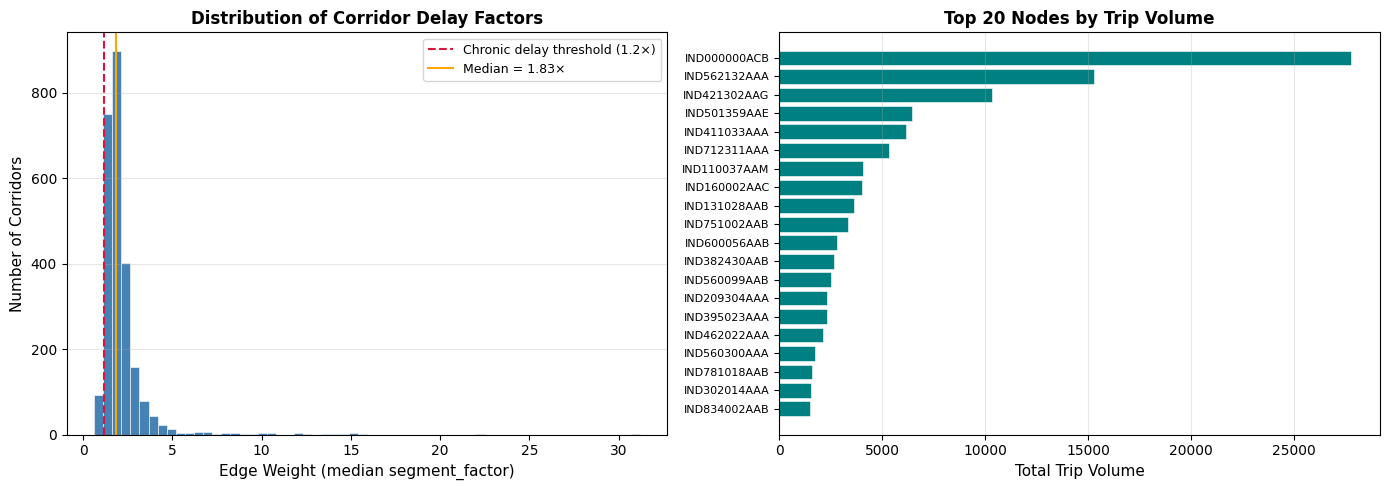

Saved: graph_overview.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: histogram of edge weights ---
ax = axes[0]
ax.hist(edge_weights, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(1.2, color='crimson', linestyle='--', linewidth=1.5, label='Chronic delay threshold (1.2×)')
ax.axvline(np.median(edge_weights), color='orange', linestyle='-', linewidth=1.5,
           label=f'Median = {np.median(edge_weights):.2f}×')
ax.set_xlabel('Edge Weight (median segment_factor)', fontsize=11)
ax.set_ylabel('Number of Corridors', fontsize=11)
ax.set_title('Distribution of Corridor Delay Factors', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# --- Right: top 20 nodes by total volume ---
ax2 = axes[1]
node_volumes = {
    n: G_all.nodes[n]['total_volume'] for n in G_all.nodes()
}
top_nodes = sorted(node_volumes, key=node_volumes.get, reverse=True)[:20]
top_vols  = [node_volumes[n] for n in top_nodes]

bars = ax2.barh(range(len(top_nodes)), top_vols, color='teal', edgecolor='white', linewidth=0.4)
ax2.set_yticks(range(len(top_nodes)))
ax2.set_yticklabels(top_nodes, fontsize=8)
ax2.invert_yaxis()
ax2.set_xlabel('Total Trip Volume', fontsize=11)
ax2.set_title('Top 20 Nodes by Trip Volume', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('graph_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: graph_overview.png')

### Saving Graph Objects

In [24]:
import pickle

with open('G_all.pkl', 'wb') as f:
    pickle.dump(G_all, f)

with open('G_rtype.pkl', 'wb') as f:
    pickle.dump(G_rtype, f)

# Also save corridor_stats as a convenience CSV
corridor_stats.to_csv('corridor_stats.csv', index=False)

print('Saved:')
print('  G_all.pkl          - combined directed graph')
print('  G_rtype.pkl        - route-type-stratified graph')
print('  corridor_stats.csv - per-corridor aggregated stats')

Saved:
  G_all.pkl          - combined directed graph
  G_rtype.pkl        - route-type-stratified graph
  corridor_stats.csv - per-corridor aggregated stats
